# Case study: How does a bike-share navigate speedy success?


<img src="https://images.ctfassets.net/p6ae3zqfb1e3/1gPC7gKckiDHHTLoqs08UU/d9d02bc98eda3f897fc07780fa0eb7d0/Divvy_Ride_experience_Hero_2x.jpg?w=2500&q=60&fm=webp" alt="Meet Alex" width="800" position="right">


## Business task
### Scenario

Cyclistic, a leading bike-share company in Chicago, has identified a significant opportunity to increase profitability by converting casual riders into annual members. Financial analyses have demonstrated that annual members are more profitable than casual riders. However, to develop effective marketing strategies aimed at this conversion, it is crucial to understand the differing usage patterns between these two user types. 

As a junior data analyst, my primary task is to analyze historical trip data to identify how annual members and casual riders use Cyclist bikes differently. This analysis will serve as the foundation for targeted marketing strategies designed to convert casual riders into annual members, thereby enhancing the company's profitability.


**Original Data Origin and Storage**: 

The initial datasets were obtained through a link provided by the [Google Data Analytics Certificate](https://www.coursera.org/professional-certificates/google-data-analytics), hosted on Coursera and backed by Motivate International Inc. The data has been made available by Motivate International Inc. under [this licence](https://divvybikes.com/data-license-agreement).

For updated and additional analysis, datasets were accessed from a publicly available Kaggle dataset provided by user Harsh Jhunjhunwala in his notebook titled "Google Capstone Project - Cyclist," and directly from Divvy's trip data hosted at https://divvy-tripdata.s3.amazonaws.com/index.html. This direct access allows real-time data usage and ensures that the analysis incorporates the most current data available.

This analysis includes a data journal and a presentation (.pptx) as part of my final project for the Google Data Analytics Specialization.

## Data Preparation

Importing and loading all the necessary libraries

In [1]:
library(tidyverse)  # Essential for data manipulation and visualization, includes packages like ggplot2, dplyr (data manipulation tasks such as filtering rows, selecting columns, and arranging data), and tidyr.
library(skimr)      # Provides compact and flexible summaries of data frames.
library(here)       # Simplifies path management in R projects by constructing paths relative to the top-level directory.
library(janitor)    # Useful for cleaning variable names and other data cleaning tasks.
library(conflicted) # Use the conflicted package to manage conflicts

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
here() starts at /kaggle/working


Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




In [2]:
# Set dplyr::filter and dplyr::lag as the default choices
conflict_prefer("filter", "dplyr")
conflict_prefer("lag", "dplyr")

[conflicted] Will prefer dplyr::filter over any other package.
[conflicted] Will prefer dplyr::lag over any other package.


In [3]:
# Note that R requires the use of `/` instead of '\' for reading the file. 
file_path <- here('/kaggle/input/cyclist/data/Divvy_Trips_2019_Q1')
trips_2019 <- read_csv(file_path)

Rows: 365069 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): from_station_name, to_station_name, usertype, gender
dbl  (5): trip_id, bikeid, from_station_id, to_station_id, birthyear
num  (1): tripduration
dttm (2): start_time, end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
file_path <- here('/kaggle/input/cyclist/data/Divvy_Trips_2020_Q1.csv')
trips_2020 <- read_csv(file_path)

Rows: 426887 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): ride_id, rideable_type, start_station_name, end_station_name, memb...
dbl  (6): start_station_id, end_station_id, start_lat, start_lng, end_lat, e...
dttm (2): started_at, ended_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
head(trips_2019)

trip_id,start_time,end_time,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,gender,birthyear
<dbl>,<dttm>,<dttm>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>
21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,2167,390,199,Wabash Ave & Grand Ave,84,Milwaukee Ave & Grand Ave,Subscriber,Male,1989
21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,4386,441,44,State St & Randolph St,624,Dearborn St & Van Buren St (*),Subscriber,Female,1990
21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,1524,829,15,Racine Ave & 18th St,644,Western Ave & Fillmore St (*),Subscriber,Female,1994
21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,252,1783,123,California Ave & Milwaukee Ave,176,Clark St & Elm St,Subscriber,Male,1993
21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,1170,364,173,Mies van der Rohe Way & Chicago Ave,35,Streeter Dr & Grand Ave,Subscriber,Male,1994
21742448,2019-01-01 00:15:33,2019-01-01 00:19:09,2437,216,98,LaSalle St & Washington St,49,Dearborn St & Monroe St,Subscriber,Female,1983


In [6]:
summary(trips_2019)


    trip_id           start_time                    
 Min.   :21742443   Min.   :2019-01-01 00:04:37.00  
 1st Qu.:21848765   1st Qu.:2019-01-23 05:26:54.00  
 Median :21961829   Median :2019-02-25 07:52:56.00  
 Mean   :21960872   Mean   :2019-02-19 21:43:15.42  
 3rd Qu.:22071823   3rd Qu.:2019-03-17 16:52:47.00  
 Max.   :22178528   Max.   :2019-03-31 23:53:48.00  
                                                    
    end_time                          bikeid      tripduration     
 Min.   :2019-01-01 00:11:07.00   Min.   :   1   Min.   :      61  
 1st Qu.:2019-01-23 05:49:40.00   1st Qu.:1777   1st Qu.:     326  
 Median :2019-02-25 08:03:50.00   Median :3489   Median :     524  
 Mean   :2019-02-19 22:00:11.91   Mean   :3429   Mean   :    1016  
 3rd Qu.:2019-03-17 17:16:16.00   3rd Qu.:5157   3rd Qu.:     866  
 Max.   :2019-06-17 16:04:35.00   Max.   :6471   Max.   :10628400  
                                                                   
 from_station_id from_station_na

Taking care of NA values:
1. Calculate the median birthyear, ignoring NA values.
2. Replace NA values with the median birthyear

In [7]:
median_birthyear <- median(trips_2019$birthyear, na.rm = TRUE)

trips_2019 <- trips_2019 %>% mutate(birthyear = if_else(is.na(birthyear), median_birthyear, birthyear))

In [8]:
head(trips_2020)

ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
EACB19130B0CDA4A,docked_bike,2020-01-21 20:06:59,2020-01-21 20:14:30,Western Ave & Leland Ave,239,Clark St & Leland Ave,326,41.9665,-87.6884,41.9671,-87.6674,member
8FED874C809DC021,docked_bike,2020-01-30 14:22:39,2020-01-30 14:26:22,Clark St & Montrose Ave,234,Southport Ave & Irving Park Rd,318,41.9616,-87.6660,41.9542,-87.6644,member
789F3C21E472CA96,docked_bike,2020-01-09 19:29:26,2020-01-09 19:32:17,Broadway & Belmont Ave,296,Wilton Ave & Belmont Ave,117,41.9401,-87.6455,41.9402,-87.6530,member
C9A388DAC6ABF313,docked_bike,2020-01-06 16:17:07,2020-01-06 16:25:56,Clark St & Randolph St,51,Fairbanks Ct & Grand Ave,24,41.8846,-87.6319,41.8918,-87.6206,member
943BC3CBECCFD662,docked_bike,2020-01-30 08:37:16,2020-01-30 08:42:48,Clinton St & Lake St,66,Wells St & Hubbard St,212,41.8856,-87.6418,41.8899,-87.6343,member
6D9C8A6938165C11,docked_bike,2020-01-10 12:33:05,2020-01-10 12:37:54,Wells St & Hubbard St,212,Desplaines St & Randolph St,96,41.8899,-87.6343,41.8846,-87.6446,member


In [9]:
glimpse(trips_2020)

Rows: 426,887
Columns: 13
$ ride_id            <chr> "EACB19130B0CDA4A", "8FED874C809DC021", "789F3C21E4…
$ rideable_type      <chr> "docked_bike", "docked_bike", "docked_bike", "docke…
$ started_at         <dttm> 2020-01-21 20:06:59, 2020-01-30 14:22:39, 2020-01-…
$ ended_at           <dttm> 2020-01-21 20:14:30, 2020-01-30 14:26:22, 2020-01-…
$ start_station_name <chr> "Western Ave & Leland Ave", "Clark St & Montrose Av…
$ start_station_id   <dbl> 239, 234, 296, 51, 66, 212, 96, 96, 212, 38, 117, 1…
$ end_station_name   <chr> "Clark St & Leland Ave", "Southport Ave & Irving Pa…
$ end_station_id     <dbl> 326, 318, 117, 24, 212, 96, 212, 212, 96, 100, 632,…
$ start_lat          <dbl> 41.9665, 41.9616, 41.9401, 41.8846, 41.8856, 41.889…
$ start_lng          <dbl> -87.6884, -87.6660, -87.6455, -87.6319, -87.6418, -…
$ end_lat            <dbl> 41.9671, 41.9542, 41.9402, 41.8918, 41.8899, 41.884…
$ end_lng            <dbl> -87.6674, -87.6644, -87.6530, -87.6206, -87.6343, -…
$ member_casua

In [10]:
summary(trips_2020)

   ride_id          rideable_type        started_at                    
 Length:426887      Length:426887      Min.   :2020-01-01 00:04:44.00  
 Class :character   Class :character   1st Qu.:2020-01-24 14:03:26.00  
 Mode  :character   Mode  :character   Median :2020-02-17 05:01:27.00  
                                       Mean   :2020-02-14 01:23:18.51  
                                       3rd Qu.:2020-03-05 15:08:13.50  
                                       Max.   :2020-03-31 23:51:34.00  
                                                                       
    ended_at                      start_station_name start_station_id
 Min.   :2020-01-01 00:10:54.00   Length:426887      Min.   :  2.0   
 1st Qu.:2020-01-24 14:21:24.50   Class :character   1st Qu.: 77.0   
 Median :2020-02-17 05:48:58.00   Mode  :character   Median :176.0   
 Mean   :2020-02-14 01:45:25.43                      Mean   :209.8   
 3rd Qu.:2020-03-05 15:27:54.00                      3rd Qu.:298.0   
 Max

To view the rows with the missing values, I will use dplyr (from tidyverse) package that helps me with the maipulation of data.
I will use the filter() function to choose the rows where I have at least one missing value, using .na() to identify them.

In [11]:
missing_end_info <- trips_2020 %>%
filter(is.na(end_station_id) | is.na(end_station_name) | is.na(end_lat) | is.na(end_lng))
missing_end_info

ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
157EAA4C4A3C8D36,docked_bike,2020-03-16 11:23:36,2020-03-16 11:23:24,HQ QR,675,NA,NA,41.8899,-87.6803,NA,NA,casual


In [12]:
#Cancelling the just one missing information row.
trips_2020 <- trips_2020 %>%
filter(!is.na(end_station_id) & !is.na(end_station_name) & !is.na(end_lat) & !is.na(end_lng))

In [13]:
#rechecking info
summary(trips_2020)

   ride_id          rideable_type        started_at                    
 Length:426886      Length:426886      Min.   :2020-01-01 00:04:44.00  
 Class :character   Class :character   1st Qu.:2020-01-24 14:03:25.00  
 Mode  :character   Mode  :character   Median :2020-02-17 05:01:00.50  
                                       Mean   :2020-02-14 01:23:12.16  
                                       3rd Qu.:2020-03-05 15:08:03.00  
                                       Max.   :2020-03-31 23:51:34.00  
    ended_at                      start_station_name start_station_id
 Min.   :2020-01-01 00:10:54.00   Length:426886      Min.   :  2.0   
 1st Qu.:2020-01-24 14:21:22.25   Class :character   1st Qu.: 77.0   
 Median :2020-02-17 05:48:17.50   Mode  :character   Median :176.0   
 Mean   :2020-02-14 01:45:19.06                      Mean   :209.8   
 3rd Qu.:2020-03-05 15:27:45.25                      3rd Qu.:298.0   
 Max.   :2020-05-19 20:10:34.00                      Max.   :675.0   
 end_s

Calculating length of trips.

In [14]:
# Given I have confirmed that my date-time strings are in a format "YYYY-MM-DD HH:MM:SS", 
# I will use ymd_hms() (lubridate package from tidyverse).
trips_2019$start_time <- ymd_hms(trips_2019$start_time)
trips_2019$end_time <- ymd_hms(trips_2019$end_time)

#I subtract start_time from end_time to get the ride length. 
# The result will be in seconds by default but it is possible to change it 
# from "secs" to "minutes" or "hours".
trips_2019$ride_length <- difftime(trips_2019$end_time, trips_2019$start_time, units = "mins")


In [15]:
# Now the same for trips_2020:
trips_2020$started_at <- ymd_hms(trips_2020$started_at)
trips_2020$ended_at <- ymd_hms(trips_2020$ended_at)

trips_2020$ride_length <- difftime(trips_2020$ended_at, trips_2020$started_at, units = "mins")

In [16]:
# Checking for duplicates
print(paste("Duplicates in first dataset:", sum(duplicated(trips_2019))))
print(paste("Duplicates in second dataset:", sum(duplicated(trips_2020))))

[1] "Duplicates in first dataset: 0"
[1] "Duplicates in second dataset: 0"


In [17]:
# Renaming columns to align information among databases¶
colnames(trips_2019) 
colnames(trips_2020)

[1] "trip_id"           "start_time"        "end_time"         
 [4] "bikeid"            "tripduration"      "from_station_id"  
 [7] "from_station_name" "to_station_id"     "to_station_name"  
[10] "usertype"          "gender"            "birthyear"        
[13] "ride_length"

[1] "ride_id"            "rideable_type"      "started_at"        
 [4] "ended_at"           "start_station_name" "start_station_id"  
 [7] "end_station_name"   "end_station_id"     "start_lat"         
[10] "start_lng"          "end_lat"            "end_lng"           
[13] "member_casual"      "ride_length"

In [18]:
trips_2019 <- trips_2019 %>%
  rename(
    start_station_id = from_station_id,
    start_station_name = from_station_name,
    end_station_id = to_station_id,
    end_station_name = to_station_name
    )

In [19]:
trips_2020 <- trips_2020 %>%
  rename(
    start_time = started_at,
    end_time = ended_at,
    usertype = member_casual
  )

To unify the terminology used in the usertype column across the two datasets (trips_2019 and trips_2020), where trips_2019 uses 'Customer' and 'Subscriber', and trips_2020 uses 'Casual' and 'Member', I will use the mutate() function along with case_when() from the dplyr package (which I have already loaded). 
I will stick with the terminology of 2020: trips_2019 users needs to change from 'Customer' to 'Casual' and 'Subscriber' to 'Member'.

In [20]:
trips_2019 <- trips_2019 %>%
mutate(usertype = case_when(
usertype == "Customer" ~ "Casual",
usertype == "Subscriber" ~ "Member",
TRUE ~ usertype  # This line keeps all other values as they are
))

#It shouldn't be necessary, but just in case, I standardize user types in trips_2020
trips_2020 <- trips_2020 %>%
mutate(usertype = case_when(
usertype == "casual" ~ "Casual",
usertype == "member" ~ "Member",
TRUE ~ usertype  # This line keeps all other values as they are
))

In [21]:
# Checking the Data Structure before merging:
# ride_id and rideable_type are both character so they can stack.
trips_2020 <- unite(trips_2020, ride_ids, ride_id, rideable_type, sep = " ")

In [22]:
trips_2020 <- trips_2020 %>%
  rename(ride_id = ride_ids
  )

Add a Year Identifier: 
Since the data comes from different years, adding a year column to each dataset before merging could help in distinguishing between the entries from 2019 and 2020 in the future analysis.

In [23]:
trips_2019 <- mutate(trips_2019, year = 2019)
trips_2020 <- mutate(trips_2020, year = 2020)
head((trips_2019))

trip_id,start_time,end_time,bikeid,tripduration,start_station_id,start_station_name,end_station_id,end_station_name,usertype,gender,birthyear,ride_length,year
<dbl>,<dttm>,<dttm>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<drtn>,<dbl>
21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,2167,390,199,Wabash Ave & Grand Ave,84,Milwaukee Ave & Grand Ave,Member,Male,1989,6.500000 mins,2019
21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,4386,441,44,State St & Randolph St,624,Dearborn St & Van Buren St (*),Member,Female,1990,7.350000 mins,2019
21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,1524,829,15,Racine Ave & 18th St,644,Western Ave & Fillmore St (*),Member,Female,1994,13.816667 mins,2019
21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,252,1783,123,California Ave & Milwaukee Ave,176,Clark St & Elm St,Member,Male,1993,29.716667 mins,2019
21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,1170,364,173,Mies van der Rohe Way & Chicago Ave,35,Streeter Dr & Grand Ave,Member,Male,1994,6.066667 mins,2019
21742448,2019-01-01 00:15:33,2019-01-01 00:19:09,2437,216,98,LaSalle St & Washington St,49,Dearborn St & Monroe St,Member,Female,1983,3.600000 mins,2019


## Analize

In [24]:
# 'Rounding' minutes. The function will convert numbers in `difftime`.
trips_2019$ride_length <- round(as.numeric(trips_2019$ride_length, units = "mins"))

trips_2020$ride_length <- round(as.numeric(trips_2020$ride_length, units = "mins"))


In [25]:
# Selecting common columns plus identification's ride and year to keep in the final dataset:

df_2019 <- select(trips_2019, trip_id, start_time, end_time, ride_length, start_station_id, start_station_name, end_station_id, end_station_name, usertype, year)
df_2020 <- select(trips_2020, ride_id, start_time, end_time, ride_length, start_station_id, start_station_name, end_station_id, end_station_name, usertype, year)

In [26]:
# Combine the datasets
combined_data <- bind_rows(df_2019, df_2020)

colnames(combined_data)

[1] "trip_id"            "start_time"         "end_time"          
 [4] "ride_length"        "start_station_id"   "start_station_name"
 [7] "end_station_id"     "end_station_name"   "usertype"          
[10] "year"               "ride_id"

In [27]:
summary(combined_data)

    trip_id           start_time                    
 Min.   :21742443   Min.   :2019-01-01 00:04:37.00  
 1st Qu.:21848765   1st Qu.:2019-02-28 17:03:58.50  
 Median :21961829   Median :2020-01-07 12:48:49.00  
 Mean   :21960872   Mean   :2019-09-01 11:57:46.86  
 3rd Qu.:22071823   3rd Qu.:2020-02-19 19:31:49.50  
 Max.   :22178528   Max.   :2020-03-31 23:51:34.00  
 NA's   :426886                                     
    end_time                       ride_length        start_station_id
 Min.   :2019-01-01 00:11:07.00   Min.   :    -9.00   Min.   :  2.0   
 1st Qu.:2019-02-28 17:15:57.50   1st Qu.:     5.00   1st Qu.: 77.0   
 Median :2020-01-07 13:02:39.00   Median :     9.00   Median :174.0   
 Mean   :2019-09-01 12:17:30.69   Mean   :    19.73   Mean   :204.4   
 3rd Qu.:2020-02-19 19:51:50.50   3rd Qu.:    15.00   3rd Qu.:291.0   
 Max.   :2020-05-19 20:10:34.00   Max.   :177200.00   Max.   :675.0   
                                                                      
 start_s

In [28]:
# Now I'll look for the day of the week for each trip.
# wday() function returns a whole number that corresponds to the day of the week, where by default 1 = Sunday, 2 = Monday, ecc. 
# Adding an argument, label = TRUE, we can see the actual day.

combined_data$weekday_start <- wday(combined_data$start_time, label = TRUE, abbr = FALSE)  #  returns the name of the day
combined_data$weekday_end <- wday(combined_data$end_time, label = TRUE, abbr = FALSE)  #Label = TRUE returns the name of the day

In [29]:
head(combined_data)

trip_id,start_time,end_time,ride_length,start_station_id,start_station_name,end_station_id,end_station_name,usertype,year,ride_id,weekday_start,weekday_end
<dbl>,<dttm>,<dttm>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<ord>,<ord>
21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,6,199,Wabash Ave & Grand Ave,84,Milwaukee Ave & Grand Ave,Member,2019,NA,Tuesday,Tuesday
21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,7,44,State St & Randolph St,624,Dearborn St & Van Buren St (*),Member,2019,NA,Tuesday,Tuesday
21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,14,15,Racine Ave & 18th St,644,Western Ave & Fillmore St (*),Member,2019,NA,Tuesday,Tuesday
21742446,2019-01-01 00:13:45,2019-01-01 00:43:28,30,123,California Ave & Milwaukee Ave,176,Clark St & Elm St,Member,2019,NA,Tuesday,Tuesday
21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,6,173,Mies van der Rohe Way & Chicago Ave,35,Streeter Dr & Grand Ave,Member,2019,NA,Tuesday,Tuesday
21742448,2019-01-01 00:15:33,2019-01-01 00:19:09,4,98,LaSalle St & Washington St,49,Dearborn St & Monroe St,Member,2019,NA,Tuesday,Tuesday


## Descriptive Statistics
### Exploratory data analysis (EDA)

Some basic `descriptive statistics` to understand the overall behavior of the two groups:

* Calculate the total number of trips for members vs. casual riders.
* Measure average ride duration for each group.
* Analyze ride distances if distance data is available or can be estimated.
* Frequency of rides across different times of the day, days of the week, and months of the year.


#### Ride lengths

In [30]:
# Descriptive analysis on ride_length (all figures in minutes)
mean(combined_data$ride_length) #straight average (total ride length / rides)
median(combined_data$ride_length) #midpoint number in the ascending array of ride lengths
max(combined_data$ride_length) #longest ride
min(combined_data$ride_length) #shortest ride


[1] 19.72937

[1] 9

[1] 177200

[1] -9

In [31]:
# Condensing the four lines above to one line using summary() on the specific attribute
summary(combined_data$ride_length)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
    -9.00      5.00      9.00     19.73     15.00 177200.00 

ok... something's not correct...
Negative values in this context are not reasonable and should be eliminated after an investigation.

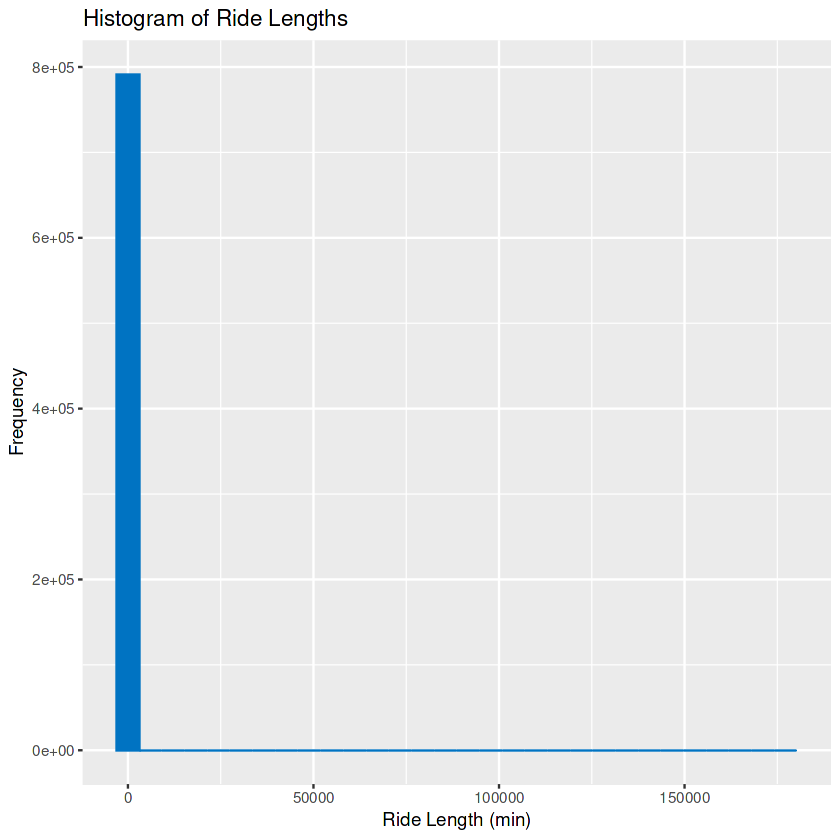

In [32]:
ggplot(combined_data, aes(x = ride_length)) + 
  geom_histogram(bins = 30, fill = "#0073C2FF", color = "#0073C2FF") +
  labs(title = "Histogram of Ride Lengths", x = "Ride Length (min)", y = "Frequency")

Also outliers are to be taken care of. 
After some investigation, I discover tThe dataframe includes a few hundred entries when bikes were taken out of docks and checked for quality by Divvy. These bikes are in a start_station_name: "HQ QR", which explains the negative values. At this point, I can create a new version of the dataframe (v2) since data is being removed.

In [33]:
combined_data_v2 <- combined_data[!(combined_data$start_station_name == "HQ QR" | combined_data$ride_length<0),]
summary(combined_data_v2)

    trip_id           start_time                    
 Min.   :21742443   Min.   :2019-01-01 00:04:37.00  
 1st Qu.:21848765   1st Qu.:2019-02-28 13:39:58.00  
 Median :21961829   Median :2020-01-07 07:59:53.00  
 Mean   :21960872   Mean   :2019-08-31 14:14:43.81  
 3rd Qu.:22071823   3rd Qu.:2020-02-19 12:38:46.00  
 Max.   :22178528   Max.   :2020-03-31 23:51:34.00  
 NA's   :423120                                     
    end_time                       ride_length        start_station_id
 Min.   :2019-01-01 00:11:07.00   Min.   :     0.00   Min.   :  2.0   
 1st Qu.:2019-02-28 13:51:45.00   1st Qu.:     6.00   1st Qu.: 77.0   
 Median :2020-01-07 08:10:57.00   Median :     9.00   Median :174.0   
 Mean   :2019-08-31 14:34:33.26   Mean   :    19.82   Mean   :202.2   
 3rd Qu.:2020-02-19 12:57:45.00   3rd Qu.:    15.00   3rd Qu.:289.0   
 Max.   :2020-05-19 20:10:34.00   Max.   :177200.00   Max.   :673.0   
                                                                      
 start_s

##### Taking care of Outliers
Using quarterlies as the IQR range (Interquartile Range). 
I will remove the outliers that are 1.5 times over the 3rd. quarterly or under the first.

In [34]:
# Calculating the IQR
IQR <- IQR(combined_data_v2$ride_length)
Q1 <- quantile(combined_data_v2$ride_length, 0.25)
Q3 <- quantile(combined_data_v2$ride_length, 0.75)

# Filtering the outliers
combined_data_v2 <- combined_data_v2 %>%
  filter(ride_length >= (Q1 - 1.5 * IQR) & ride_length <= (Q3 + 1.5 * IQR))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   5.000   8.000   9.958  13.000  28.000 

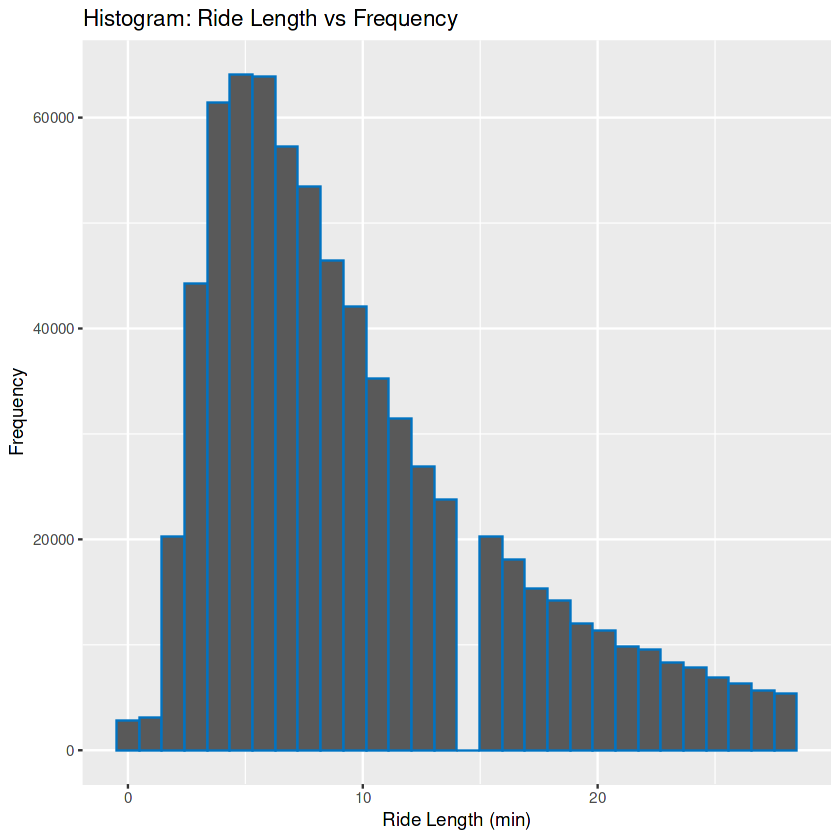

In [35]:
# Trying again
summary(combined_data_v2$ride_length)

ggplot(combined_data_v2, aes(x = ride_length)) +
  geom_histogram(bins = 30, color = "#0073C2FF") + # Adding bins for an easier visualization
  labs(title = "Histogram: Ride Length vs Frequency", x = "Ride Length (min)", y = "Frequency")

### Segmented Usage Analysis
Diving deeper into how each group uses the bikes differently:

. Usage patterns by time of day: Do members prefer commuting hours while casuals prefer afternoons or weekends?
. Duration of trips: Are casual riders’ trips longer than those of members?
. Seasonal variations: Does usage spike during certain seasons or events for one group more than the other?
. Station analysis: Are there specific stations that are predominantly used by one group over the other? 
  No pertinent for lack of data



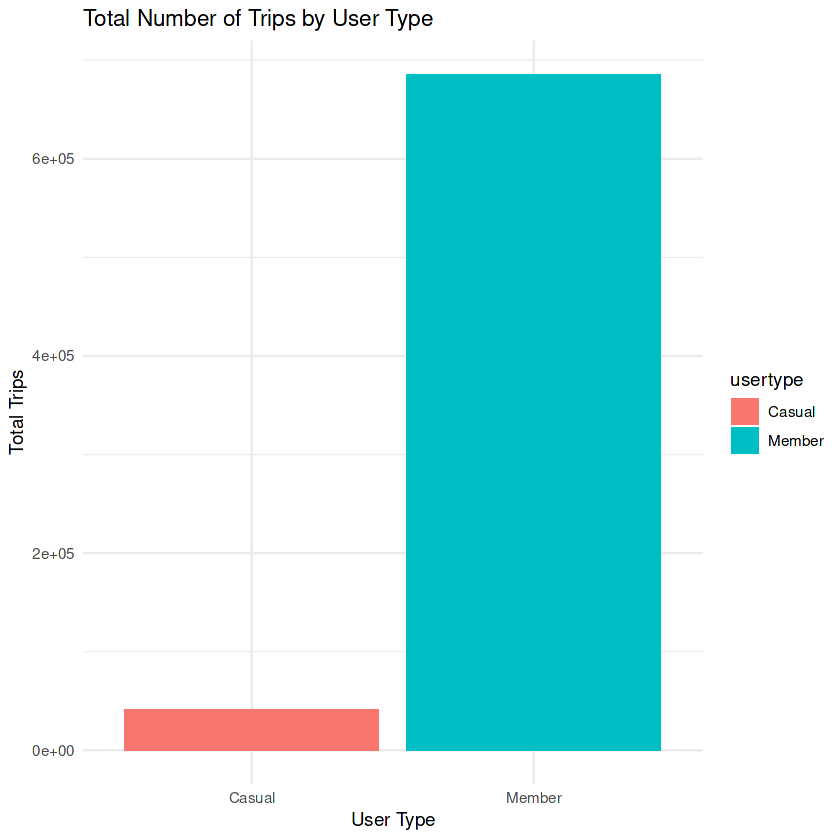

In [36]:
# Total Number of Trips by User Type (library(dplyr))

trip_counts <- combined_data_v2 %>%
  group_by(usertype) %>%
  summarise(total_trips = n())

ggplot(trip_counts, aes(x = usertype, y = total_trips, fill = usertype)) +
  geom_bar(stat = "identity") +
  labs(title = "Total Number of Trips by User Type", x = "User Type", y = "Total Trips") +
  theme_minimal()

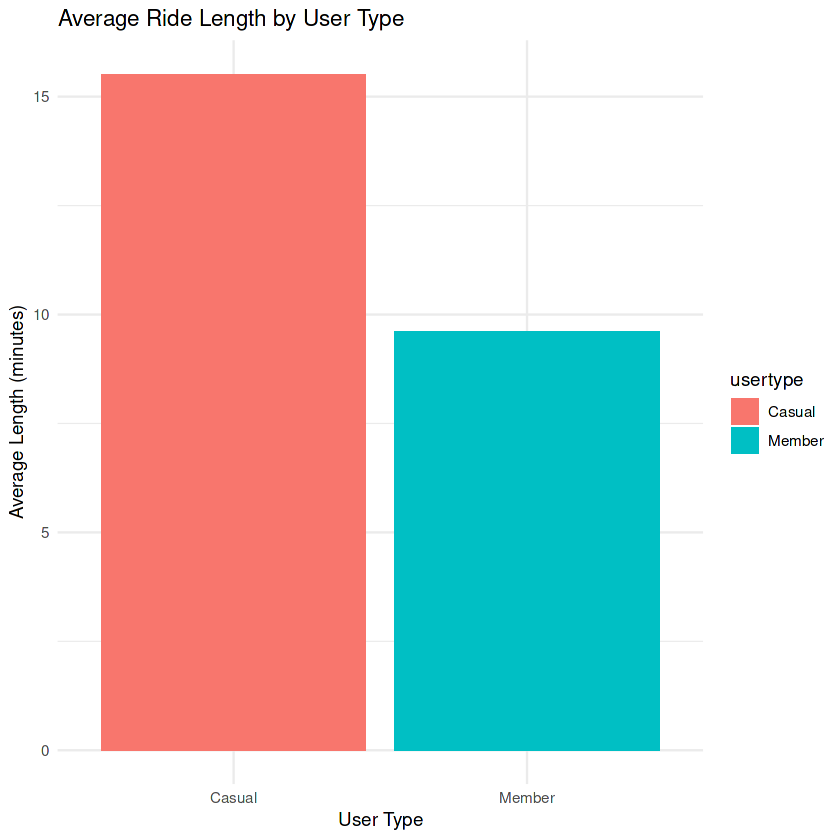

In [37]:
# Average Ride length for each usertype's group.

average_length <- combined_data_v2 %>%
  group_by(usertype) %>%
  summarise(average_length = mean(ride_length , na.rm = TRUE)
  )

ggplot(average_length, aes(x = usertype, y = average_length, fill = usertype)) +
  geom_bar(stat = "identity") +
  labs(title = "Average Ride Length by User Type", x = "User Type", y = "Average Length (minutes)") +
  theme_minimal()


#### Frequency of Rides Across Different Times of the Day

Given start_time is in POSIXct format, we can extract the hour to see when users typically start their ride, using a line plot to visualize the frequency of rides across different hours of the day for each user type.

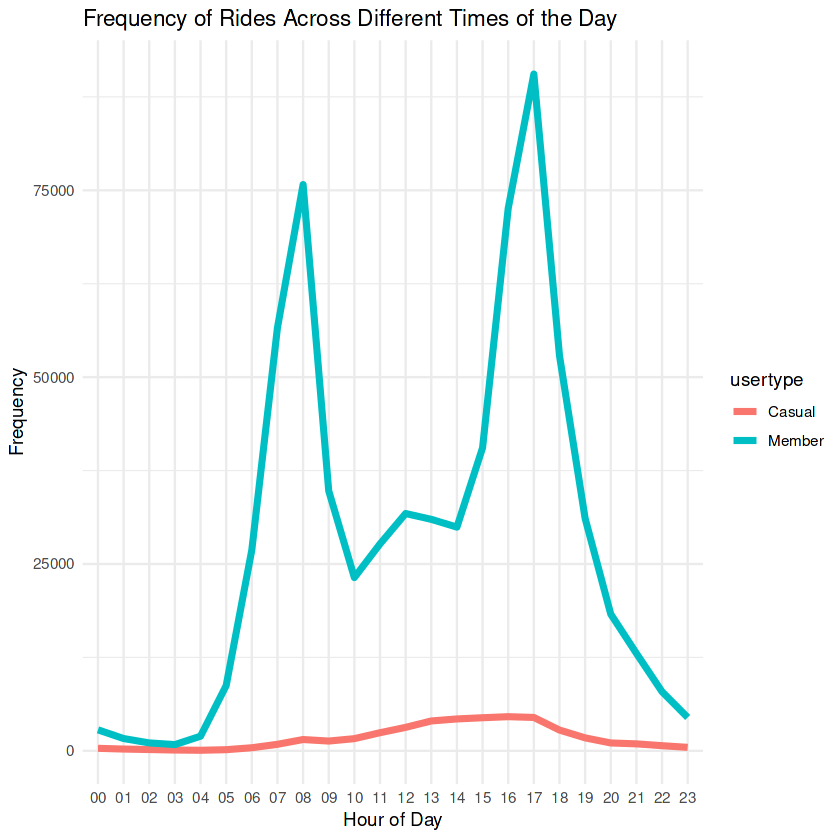

In [38]:
combined_data_v2$hour_of_day <- format(combined_data_v2$start_time, "%H")

hourly_frequency <- combined_data_v2 %>%
  group_by(usertype, hour_of_day) %>%
  summarise(frequency = n(), .groups = "drop")  # Include .groups = "drop" here to avoid a painful message


ggplot(hourly_frequency, aes(x = hour_of_day, y = frequency, color = usertype, group = usertype)) +
  geom_line(linewidth = 1.5) +
  labs(title = "Frequency of Rides Across Different Times of the Day", x = "Hour of Day", y = "Frequency") +
  theme_minimal()

#### Usage by Day of the Week

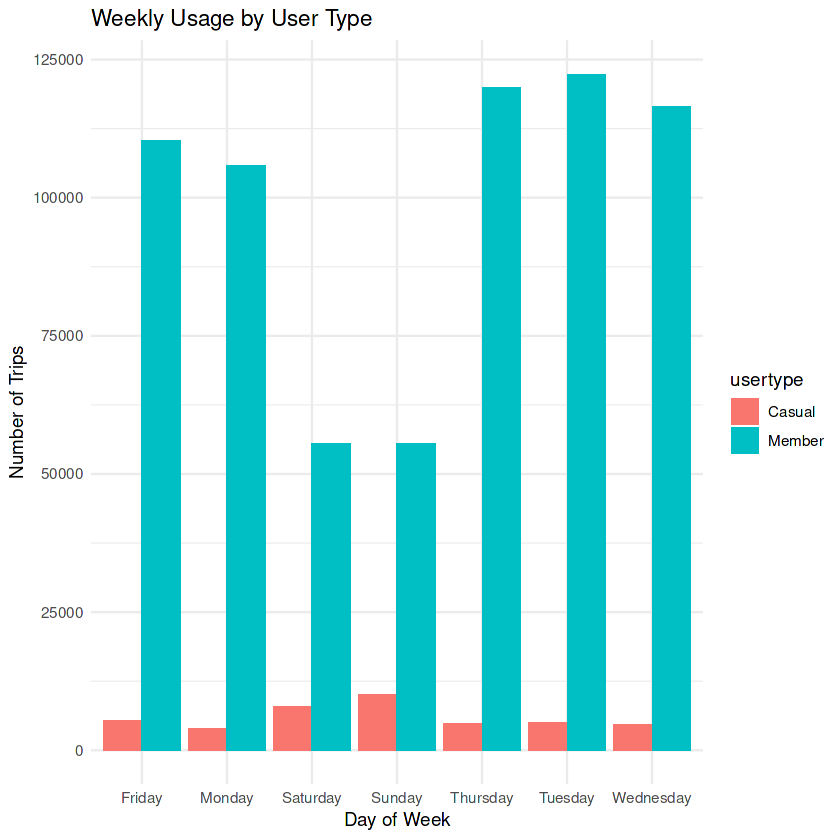

In [39]:
combined_data_v2$day_of_week <- weekdays(combined_data_v2$start_time)

weekly_usage <- combined_data_v2 %>%
  group_by(usertype, day_of_week) %>%
  summarise(weekly_trips = n(), .groups = "drop") 

ggplot(weekly_usage, aes(x = day_of_week, y = weekly_trips, fill = usertype)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Weekly Usage by User Type", x = "Day of Week", y = "Number of Trips") +
  theme_minimal()

#### Usage by Month

Extract the Month:
I will use the month() function from lubridate to extract the month as a number (1 = January, 12 = December). Given I  want the name of the month, I will use the label = TRUE argument.

In [40]:
combined_data_v2$month <- month(combined_data_v2$start_time, label = TRUE, abbr = FALSE)  # `abbr = FALSE` for full month name

head(combined_data_v2)


trip_id,start_time,end_time,ride_length,start_station_id,start_station_name,end_station_id,end_station_name,usertype,year,ride_id,weekday_start,weekday_end,hour_of_day,day_of_week,month
<dbl>,<dttm>,<dttm>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<ord>,<ord>,<chr>,<chr>,<ord>
21742443,2019-01-01 00:04:37,2019-01-01 00:11:07,6,199,Wabash Ave & Grand Ave,84,Milwaukee Ave & Grand Ave,Member,2019,NA,Tuesday,Tuesday,00,Tuesday,January
21742444,2019-01-01 00:08:13,2019-01-01 00:15:34,7,44,State St & Randolph St,624,Dearborn St & Van Buren St (*),Member,2019,NA,Tuesday,Tuesday,00,Tuesday,January
21742445,2019-01-01 00:13:23,2019-01-01 00:27:12,14,15,Racine Ave & 18th St,644,Western Ave & Fillmore St (*),Member,2019,NA,Tuesday,Tuesday,00,Tuesday,January
21742447,2019-01-01 00:14:52,2019-01-01 00:20:56,6,173,Mies van der Rohe Way & Chicago Ave,35,Streeter Dr & Grand Ave,Member,2019,NA,Tuesday,Tuesday,00,Tuesday,January
21742448,2019-01-01 00:15:33,2019-01-01 00:19:09,4,98,LaSalle St & Washington St,49,Dearborn St & Monroe St,Member,2019,NA,Tuesday,Tuesday,00,Tuesday,January
21742449,2019-01-01 00:16:06,2019-01-01 00:19:03,3,98,LaSalle St & Washington St,49,Dearborn St & Monroe St,Member,2019,NA,Tuesday,Tuesday,00,Tuesday,January


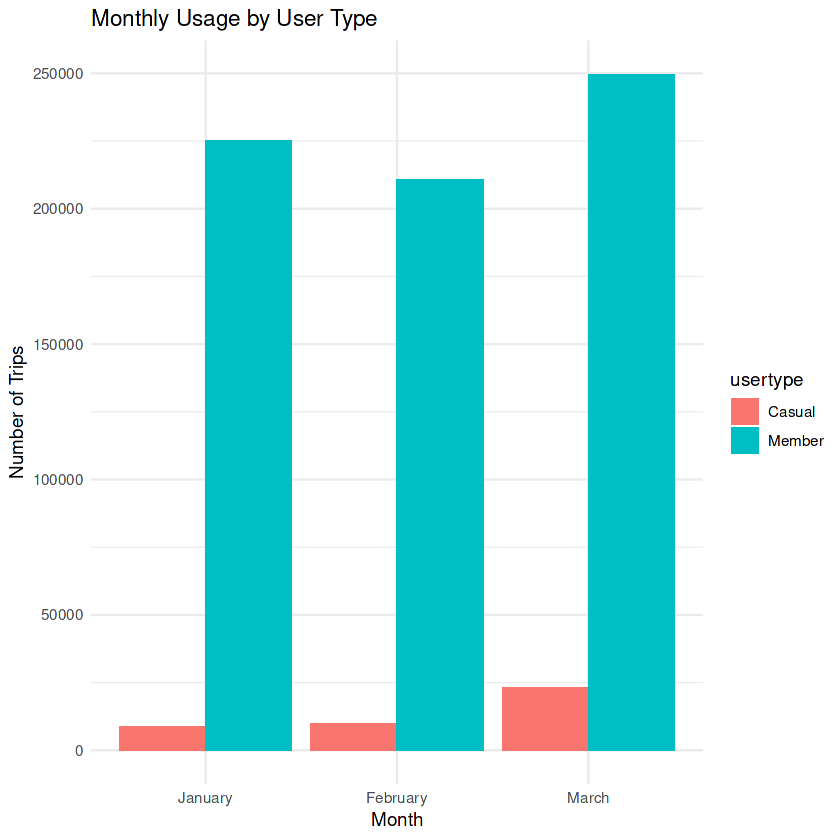

In [41]:
monthly_usage <- combined_data_v2 %>%
  group_by(usertype, month) %>%
  summarise(monthly_trips = n(), .groups = "drop")  # Include .groups = "drop" here

ggplot(monthly_usage, aes(x = month, y = monthly_trips, fill = usertype,)) +
  geom_bar(stat = "identity", position = "dodge") +
  labs(title = "Monthly Usage by User Type", x = "Month", y = "Number of Trips") +
  theme_minimal()

Temporal Changes: having the possibility to access to more data would allow a study on different months or seasons to plan for demand fluctuations.

In [42]:
print(trip_counts)
print(average_length)
print(hourly_frequency)
print(weekly_usage)
print(monthly_usage)

# A tibble: 2 × 2
  usertype total_trips
  <chr>          <int>
1 Casual         41815
2 Member        685953
# A tibble: 2 × 2
  usertype average_length
  <chr>             <dbl>
1 Casual            15.5 
2 Member             9.62
# A tibble: 48 × 3
   usertype hour_of_day frequency
   <chr>    <chr>           <int>
 1 Casual   00                338
 2 Casual   01                241
 3 Casual   02                175
 4 Casual   03                109
 5 Casual   04                 77
 6 Casual   05                155
 7 Casual   06                415
 8 Casual   07                875
 9 Casual   08               1514
10 Casual   09               1309
# ℹ 38 more rows
# A tibble: 14 × 3
   usertype day_of_week weekly_trips
   <chr>    <chr>              <int>
 1 Casual   Friday              5438
 2 Casual   Monday              3874
 3 Casual   Saturday            7994
 4 Casual   Sunday             10086
 5 Casual   Thursday            4827
 6 Casual   Tuesday             4945
 7 Casual

### First insights


#### Visualizations confirm **Distinct Patterns of bike usage between Casual riders and Members**.

#### Ride Duration Differences

**Casual riders tend to use bikes for longer duration than members**. This might indicate that casual riders are using bikes for leisure or non-commuting purposes, whereas members might be using them for regular, possibly shorter, commutes.

#### Time Preferences

**Casual Riders: No strong preference for a specific hour**, but a higher usage during weekends suggests leisure or errand activities that **align with free time**.
**Members: Peak usage early in the morning (6:30-9 AM) and late afternoon to early evening (15-19 PM)** on weekdays indicates commuting **to and from work**.

#### Day of the Week Trends:

**Casual riders show increased activity over the weekends**, aligning with **leisure use**.
**Members have consistent higher use during weekdays**, supporting the **commuting hypothesis**.


### Suggestions for Further Analysis

1. Given these findings, identifying if there are specific routes or stations that are preferred by casual riders versus members could help in optimizing bike and dock availability.

2. Promotional Strategies: For casual riders who use bikes longer and mainly on weekends, promotional offers could be targeted for converting them into members by showcasing the cost benefits of membership for frequent use.

3. Feedback and Survey Data: If available, analyzing user feedback or survey data could provide insights into why members choose short rides and casual riders prefer longer ones, helping tailor services to each group’s needs.


### Next steps
Determining the most frequently used stations for both starting and ending rides for each user type.



<img src="https://s3.amazonaws.com/medill.wordpress.offload/WP%20Media%20Folder%20-%20medill-reports-chicago/wp-content/uploads/sites/3/2016/01/jennygzhang_divvy_1.jpg" width="800">

In [43]:

# Count starts and ends at each station for each user type
station_usage <- combined_data_v2 %>%
  group_by(usertype, start_station_name, end_station_name) %>%
  summarise(starts = n(), ends = n(), .groups = 'drop') %>%
  arrange(desc(starts), desc(ends))

In [44]:
# View top stations for casual users and members
head(filter(station_usage, usertype == "Casual"), 10)
head(filter(station_usage, usertype == "Member"), 10)

usertype,start_station_name,end_station_name,starts,ends
<chr>,<chr>,<chr>,<int>,<int>
Casual,Lake Shore Dr & Monroe St,Streeter Dr & Grand Ave,482,482
Casual,Lake Shore Dr & Monroe St,Lake Shore Dr & Monroe St,338,338
Casual,Shedd Aquarium,Streeter Dr & Grand Ave,212,212
Casual,Shedd Aquarium,Millennium Park,180,180
Casual,Streeter Dr & Grand Ave,Streeter Dr & Grand Ave,152,152
Casual,Lake Shore Dr & Monroe St,Shedd Aquarium,150,150
Casual,Dusable Harbor,Streeter Dr & Grand Ave,148,148
Casual,Shedd Aquarium,Lake Shore Dr & Monroe St,137,137
Casual,Streeter Dr & Grand Ave,Millennium Park,123,123


usertype,start_station_name,end_station_name,starts,ends
<chr>,<chr>,<chr>,<int>,<int>
Member,Michigan Ave & Washington St,Clinton St & Washington Blvd,961,961
Member,Canal St & Adams St,Michigan Ave & Washington St,897,897
Member,Columbus Dr & Randolph St,Clinton St & Washington Blvd,840,840
Member,Canal St & Madison St,Michigan Ave & Washington St,837,837
Member,Michigan Ave & Washington St,Canal St & Adams St,790,790
Member,Clinton St & Washington Blvd,Michigan Ave & Washington St,694,694
Member,Columbus Dr & Randolph St,State St & Randolph St,684,684
Member,Lake Park Ave & 56th St,University Ave & 57th St,673,673
Member,Wacker Dr & Washington St,Michigan Ave & Washington St,668,668


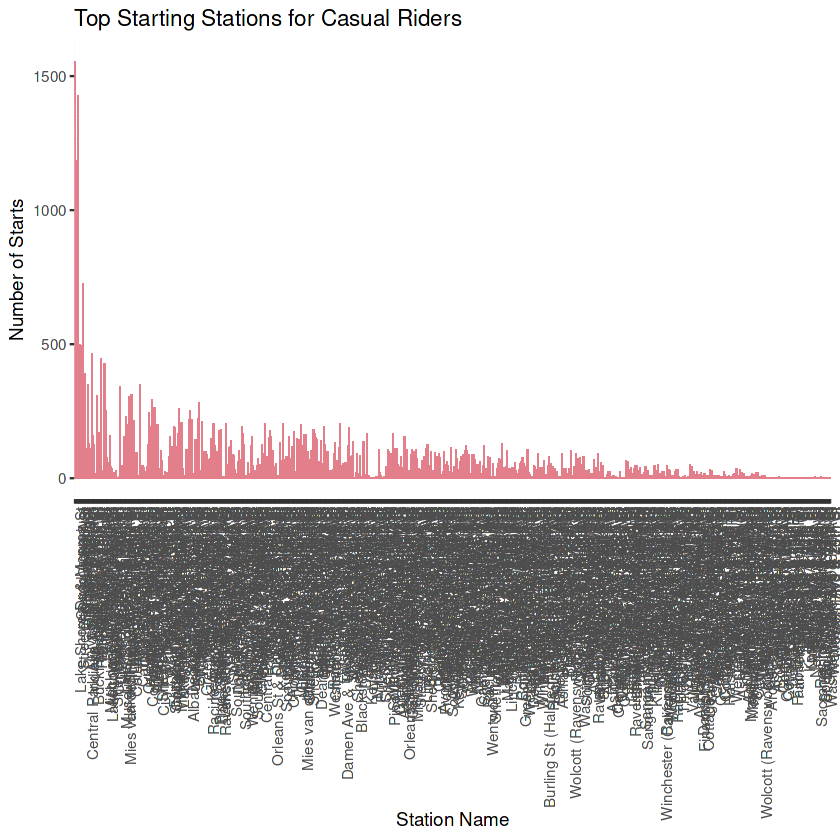

In [45]:
# Visualize Station Usage
ggplot(filter(station_usage, usertype == "Casual"), aes(x = reorder(start_station_name, -starts), y = starts)) +
  geom_bar(stat = "identity", fill = "#e27f8b") +
  labs(title = "Top Starting Stations for Casual Riders", x = "Station Name", y = "Number of Starts") +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

Even if the visualization with all the stations indeed looks quite crowded, it is easy to see a clear pattern from the plot: instead of attempting to display all stations, I'll focus on the top stations where the bulk of the activity is concentrated. This will reduce clutter and make trends more apparent.

In [46]:
# Filter for the top 20 stations for Casual riders
# Aggregate data to sum up starts at each station
station_aggregated <- station_usage %>%
  filter(usertype == "Casual") %>%
  group_by(start_station_name) %>%
  summarise(total_starts = sum(starts), .groups = 'drop')

# Now apply top_n to the aggregated data
top_stations <- station_aggregated %>%
  top_n(20, total_starts)
nrow(top_stations)  # This should return 20

[1] 20

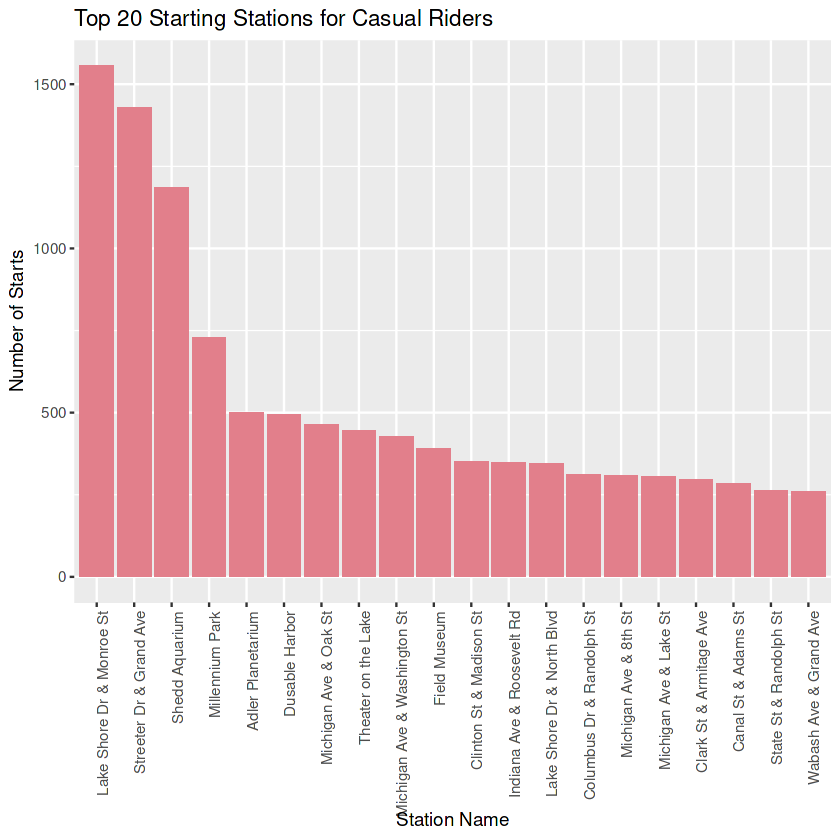

In [47]:
ggplot(top_stations, aes(x = reorder(start_station_name, -total_starts), y = total_starts)) +
  geom_bar(stat = "identity", fill = "#e27f8b") +
  labs(title = "Top 20 Starting Stations for Casual Riders", x = "Station Name", y = "Number of Starts") +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

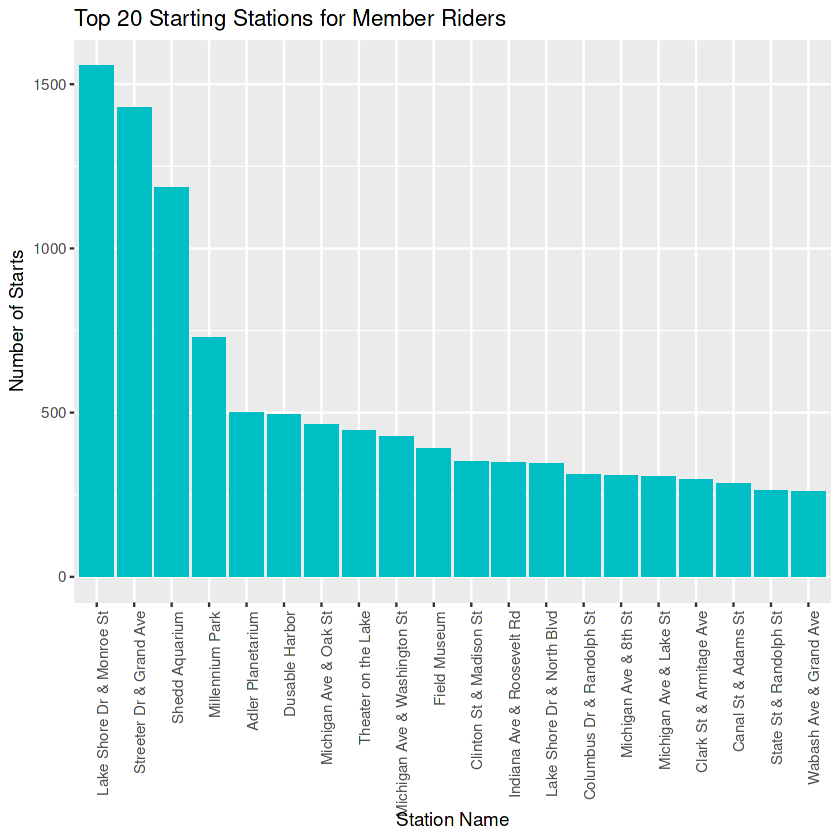

In [48]:
# Filtering member_stations by usertype
# plotting
# Plotting code with the correct data
ggplot(top_stations, aes(x = reorder(start_station_name, -total_starts), y = total_starts)) +
  geom_bar(stat = "identity", fill = "#00bfc4") +
  labs(title = "Top 20 Starting Stations for Member Riders", x = "Station Name", y = "Number of Starts") +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))


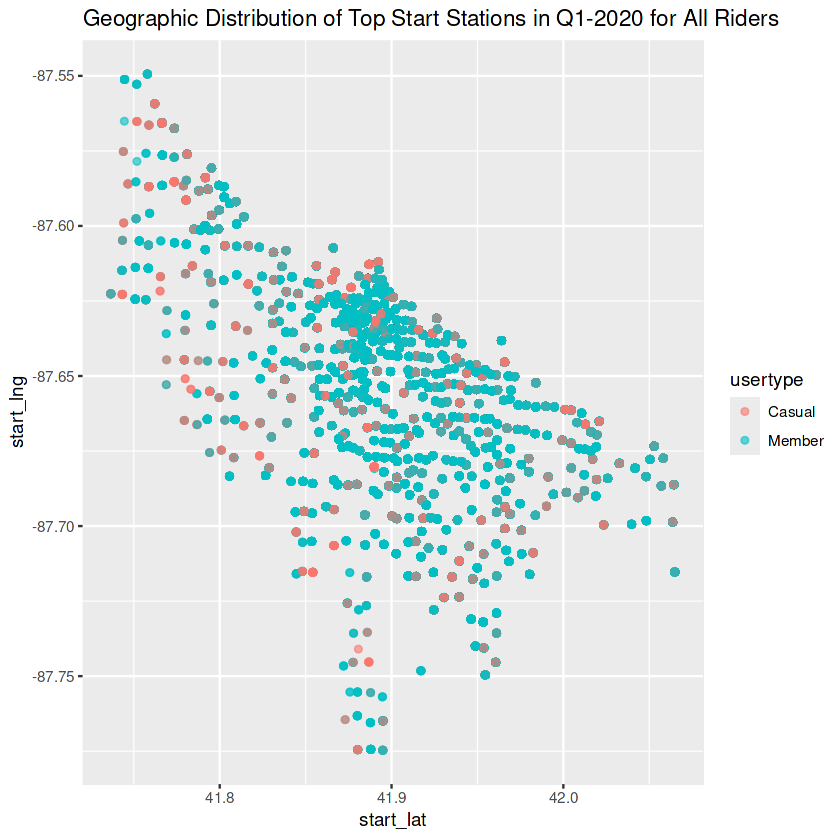

In [49]:
# Using the latitude and longitude data avILble: 
# Info available only for the first quarter of 2020 but it could be interesting for further studies.

ggplot(data = trips_2020, aes(x = start_lat, y = start_lng, color = usertype)) +
  geom_point(alpha = 0.6) +
  labs(title = "Geographic Distribution of Top Start Stations in Q1-2020 for All Riders")


## Summary of the Cyclistic Case Study


### Study Objective:

Examine the behavior of customers of Cyclistic, a leading bike-sharing company in Chicago, to **identify opportunities to convert casual users into annual members**. This conversion is key to **increasing the company's profitability**.

### Methodology:

The case study employs a **data-driven approach**, analyzing travel data from the bike-sharing service's users. The analyses focus on various user behavior aspects, including `trip durations`, `usage frequency`, and `station preferences`. The code and analyses are implemented in **R**, using packages such as tidyverse, lubridate, and here for data manipulation, and ggplot2 for visualization.

### Key Findings:

* **Trip Duration Analysis**: Annual users tend to have shorter but more frequent trips compared to casual users.
Ride Frequency: Peak times show significant differences in behaviors between the two user types, with distinct peaks that could indicate targeted marketing opportunities.
* **Station Usage**: Certain stations are favored by casual users versus annual members, suggesting areas for specific promotional interventions.
* **Visualizations**: Key graphs include histograms of trip durations, bar charts of the total number of trips by user type, and maps showing the geographic distribution of the most frequented stations. These visualizations help to visually identify user behavior patterns.

### Conclusions and Recommendations:

* Conversion Incentives: Based on the analysis, it is recommended to introduce time-based incentives during peak hours and promotions at stations with high casual user activity.
* Infrastructure Improvements: Enhance stations with high activity to improve user experience and support an increase in service usage.
* Targeted Marketing Campaigns: Use the analyzed data for targeted advertising campaigns that encourage the conversion of casual users into annual members.


## Appendix

* **Data Sources and Preparation for Cyclistic Bike-Share Analysis**
Data Origin and Storage: The original datasets were obtained through a link provided by the Google Data Analytics Certificate, hosted on Coursera and backed by Motivate International Inc. The data is stored locally on my computer with a backup on Posit Cloud, ensuring both accessibility and security.

* **Data Description**:

The data comprises two CSV files, each containing details of trips made by Cyclistic bike-share customers in Chicago. Each file includes 13 or 14 columns, detailing aspects of each trip such as start time, end time, trip duration, and type of user (subscriber or customer). The datasets represent a comprehensive view of bike usage patterns, tailored to understand customer behaviors without compromising personal identity.

* **Data Organization**:

Data is organized in spreadsheets with columns consistently named across files to ensure uniformity. Each row in the datasets corresponds to a single trip, with comprehensive data points collected for analysis.

* **Credibility and Reliability**:

The data's credibility is assured by its acquisition from a reputable source—Motivate International Inc., known for their management of bike-share programs. The datasets adhere to the ROCCC principles—being Relevant, Original, Comprehensive, Current, and Cited, which strengthens their suitability for detailed analytical tasks.

* **Licensing, Privacy, and Security**:

The data usage is governed by a license agreement from Motivate International Inc., which is respected and adhered to in this analysis. Privacy concerns are paramount, with no personal identifying information used in the study. Security is maintained through local storage and controlled cloud backup.

* **Data Integrity and Cleaning**:

No specific integrity checks were needed beyond basic data cleaning, which involved addressing missing values and ensuring column name consistency across datasets. Duplicates were checked and none were found, confirming the data’s readiness for analysis.

* **Use and Limitations**:

This dataset allows for an in-depth analysis of bike usage patterns among different types of users in Chicago. It helps in understanding the dynamics of bike rentals, which is crucial for strategic decisions by Cyclistic. However, the analysis is limited by the inability to access personally identifiable information, ensuring user privacy but restricting certain types of deeper behavioral analysis.

* **Preparation for Analysis**:

All data has been prepared with necessary cleaning steps completed, including standardization of column names and removal of any duplicates. The data is now structured and ready for detailed statistical analysis and visualization to answer specific business questions.

* **Image Credits**:

Images sourced from Divvy's official site.
Additional imagery provided by Northwestern University’s Medill School of Journalism, Media, Integrated Marketing Communications.


* **Review of Case Studies**:

  * https://medium.com/@Urbica.co/improving-moscows-bike-share-f58007a932d5
  * https://blog.producthunt.com/we-tried-every-shared-bike-and-scooter-in-san-francisco-bb766abd0a96
  * https://github.com/MilanRibel/CASE_Ordina
  * https://public.tableau.com/app/profile/ritika.gupta4235/viz/BikeSharingDashboard/BikeSharing
  


In [50]:
# Save your data
# write.csv(combined_data_v2, "combined_data_v2.csv", row.names = FALSE)